В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функції, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим, виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозмірний, для цього, можливо, треба буде трансформувати Ваші дані X в формат, як було в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдені параметри моделі близькими до ваших найкращих припущень?

In [1]:
# Імпортування потрібних бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Вивантаження набору даних medical_df
medical_df = pd.read_csv('medical-charges.csv')

# Задання набору даних non_smoker_df для клієнтів страхової компанії, які не курять
non_smoker_df = medical_df[medical_df.smoker == 'no']

Коефіцієнти методу найменших квадратів: -2091.4205565650823, 267.2489128311996


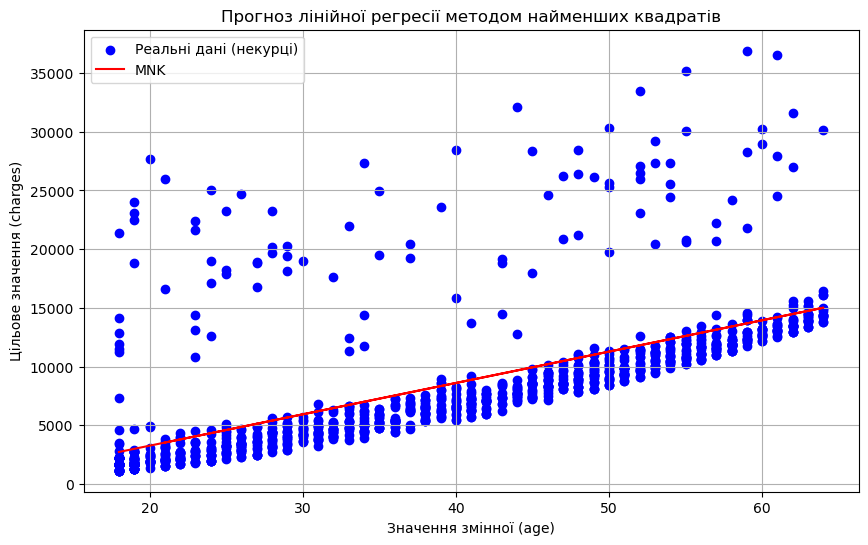

Root mean squared error для параметрів 267.2489128311996 та -2091.4205565650823, знайдених методом найменших квадратів: 4662.505766636395


In [27]:
# 1.1. Відшукання найкращої лінії для прогнозу charges за ознакою age для некурців (датафрейм non_smoker_df) з допомогою
# методу найменших квадратів (з використанням тільки numpy)

# Визначення матриці ознак та вектора цільових значень з набору даних non_smoker_df
X = non_smoker_df[['age']].values       # Матриця ознак (двовимірний масив)
y = non_smoker_df['charges'].values     # Вектор цільових значень

# Задання функції для обчислення нормальних рівнянь лінійної регресії
def normal_equations(X, y):
    """Обчислює закрите рішення лінійної регресії"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

# Додавання колонки одиничок (константи в моделі регресії)
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

# Обчислення коефіцієнтів методу найменших квадратів
MNK_coefs = normal_equations(X_with_intercept, y)

# Виведення коефіцієнтів методу найменших квадратів
print(f"Коефіцієнти методу найменших квадратів: {MNK_coefs[0]}, {MNK_coefs[1]}")

# Обчислення та збереження в окрему змінну прогнозів моделі для методу найменших квадратів
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)

# Візуалізація найкращої лінії, знайденої методом найменших квадратів, та справжніх значень набору даних non_smoker_df

# Задання розмірів фігури
plt.figure(figsize = (10, 6))
# Задання справжніх значень набору даних non_smoker_df
plt.scatter(X[:, 0], y, color = 'blue', label = 'Реальні дані (некурці)')
# Задання лінії передбачуваних значень
plt.plot(X[:, 0], predictions_MNK, color = 'red', label = 'MNK')
# Задання підписів осей 0x, 0y, легенди та сітки
plt.title('Прогноз лінійної регресії методом найменших квадратів')
plt.xlabel('Значення змінної (age)')
plt.ylabel('Цільове значення (charges)')
plt.legend()
plt.grid(True)
# Виведення графіка
plt.show()

# Обчислення root mean squared error для методу найменших квадратів

# Створення функції для обчислення root mean squared error
def rmse_MNK(df, w, b):

  # Витягування значень стовпця charges
  target = df.charges

  # Витягування значень, прогнозованих методом найменших квадратів
  predicted = predictions_MNK

  # Обчислення root mean squared error для кожного прогнозованого значення
  rmse_value = np.sqrt(np.mean((target - predicted) ** 2))
  return rmse_value

# Виведення root mean squared error для коефіцієнтів, обчислених методом найменших квадратів
print(f"Root mean squared error для параметрів {MNK_coefs[1]} та {MNK_coefs[0]}, знайдених методом найменших квадратів: {rmse_MNK(non_smoker_df, MNK_coefs[1], MNK_coefs[0])}")

Оптимальний коефіцієнт нахилу (m): 221.1045843794301
Оптимальний коефіцієнт зсуву (b): -41.98126853149978


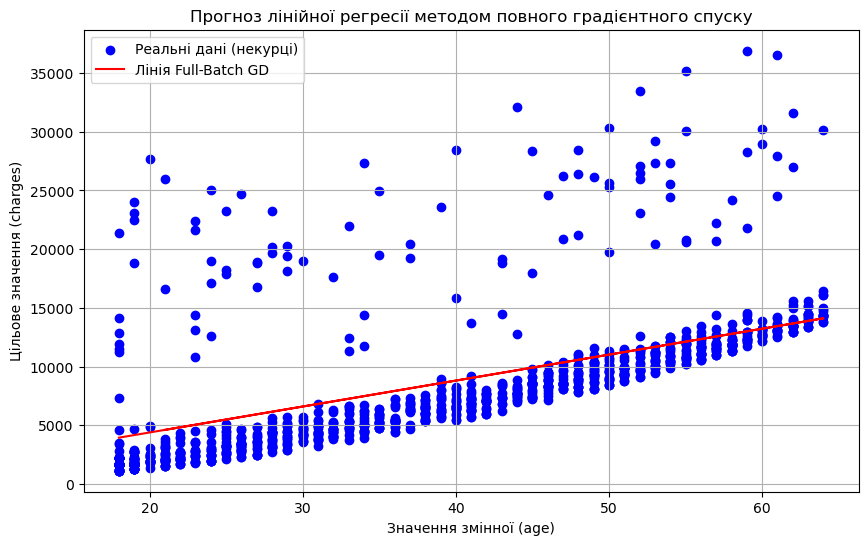

Root mean squared error для параметрів 221.1045843794301 та -41.98126853149978, знайдених методом повного градієнтного спуску: 4713.250582815521


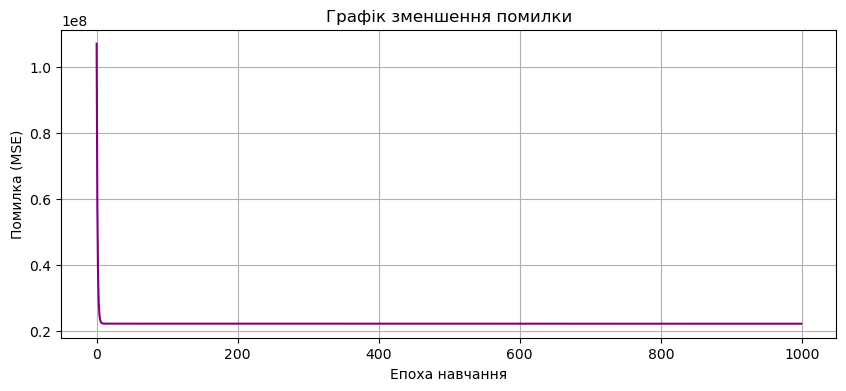

In [28]:
# 1.2. Відшукання найкращої лінії для прогнозу charges за ознакою age для некурців (датафрейм non_smoker_df) з допомогою
# методу Full-Batch градієнтного спуску (з використанням тільки numpy) (для lr = 0.0001, epochs = 1000)

# Визначення ознаки (X) та цільової змінної (y) як одновимірних масивів NumPy
X = non_smoker_df['age'].values       # Вік клієнтів
y = non_smoker_df['charges'].values   # Страхові витрати

# Задання функції Full-Batch градієнтного спуску
def full_batch_gradient_descent(X, y, lr = 0.0001, epochs = 1000):
    """
    Оптимізує параметри лінійної регресії (m та b) методом
    повного (Full-Batch) градієнтного спуску.
    
    Параметри:
      X: масив ознак (вік)
      y: масив цільових значень (витрати)
      lr: крок навчання (learning rate)
      epochs: кількість ітерацій алгоритму
    """
    # Ініціалізація початкових коефіцієнтів: нахил (m) та зсув (b) нулями
    m, b = 0.0, 0.0  
    
    # Кількість спостережень (розмір вибірки)
    n = len(y)
    
    # Список для відстеження динаміки зміни помилки (функції втрат MSE)
    errors = []
    
    # Головний цикл навчання (проходження по всіх епохах)
    for _ in range(epochs):
        # Множення поточного коефіцієнта нахилу на X та додавання зсуву b.
        # Отримання вектор прогнозів для всіх об'єктів вибірки одночасно.
        y_pred = m * X + b
        
        # Обчислення різниці (помилки) між прогнозом та реальними даними
        error = y_pred - y
        
        # Обчислення середньоквадратичної помилки (MSE) для поточної епохи та додавання її в список
        mse = np.mean(error ** 2)
        errors.append(mse)
        
        # Обчислення часткової похідної функції втрат по параметру m (градієнт для m)
        m_gradient = (2 / n) * np.dot(error, X)
        
        # Обчислення часткової похідної функції втрат по параметру b (градієнт для b)
        b_gradient = (2 / n) * np.sum(error)
        
        # Крок градієнтного спуску: оновлення параметрів у напрямку,
        # протилежному до градієнта, помноженому на швидкість навчання (lr)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
        
    # Повернення знайдених оптимальних коефіцієнтів та історії помилок
    return m, b, errors

# Запуск алгоритму (lr підібрано дуже малим, щоб уникнути розбіжності методу)
m, b, errors = full_batch_gradient_descent(X, y, lr = 0.0001, epochs = 1000)

# Побудова фінальних прогнозів моделі за допомогою знайдених коефіцієнтів m та b
predictions_fbgd = m * X + b

# Виведення отриманих коефіцієнтів лінійної регресії
print(f"Оптимальний коефіцієнт нахилу (m): {m}")
print(f"Оптимальний коефіцієнт зсуву (b): {b}")

# Створення графіку для візуалізації лінії регресії, знайденої методом повного (Full-Batch) градієнтного спуску, поверх реальних даних
plt.figure(figsize = (10, 6))
plt.scatter(X, y, color = 'blue', label = 'Реальні дані (некурці)')
plt.plot(X, predictions_fbgd, color = 'red', label = 'Лінія Full-Batch GD')
plt.xlabel('Значення змінної (age)')
plt.ylabel('Цільове значення (charges)')
plt.title('Прогноз лінійної регресії методом повного градієнтного спуску')
plt.legend()
plt.grid(True)
plt.show()

# Створення функції для обчислення root mean squared error для методу повного градієнтного спуску
def rmse_FBGD(df, w, b):

  # Витягування значень стовпця charges
  target = df.charges

  # Витягування значень, прогнозованих методом найменших квадратів
  predicted = predictions_fbgd

  # Обчислення root mean squared error для кожного прогнозованого значення
  rmse_value = np.sqrt(np.mean((target - predicted) ** 2))
  return rmse_value

# Виведення root mean squared error для коефіцієнтів, обчислених методом повного градієнтного спуску
print(f"Root mean squared error для параметрів {m} та {b}, знайдених методом повного градієнтного спуску: {rmse_FBGD(non_smoker_df, m, b)}")

# Виведення графіка помилки залежно від ітерації
plt.figure(figsize = (10, 4))
plt.plot(errors, color = 'purple')
plt.xlabel('Епоха навчання')
plt.ylabel('Помилка (MSE)')
plt.title('Графік зменшення помилки')
plt.grid(True)
plt.show()

Оптимальний коефіцієнт нахилу (m): 229.61200062335735
Оптимальний коефіцієнт зсуву (b): -419.8269036279835


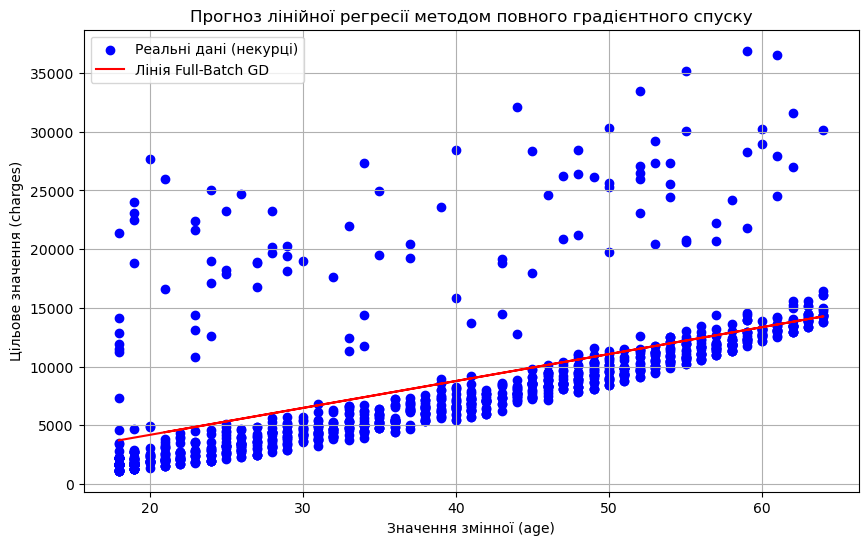

Root mean squared error для параметрів 229.61200062335735 та -419.8269036279835, знайдених методом повного градієнтного спуску: 4696.325306932077


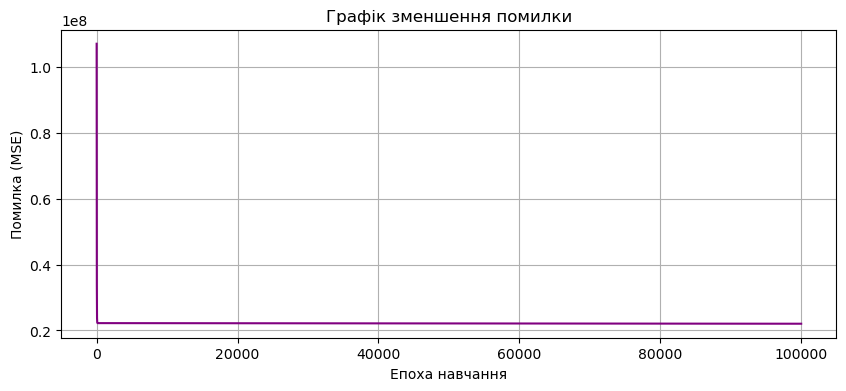

In [29]:
# 1.2. Відшукання найкращої лінії для прогнозу charges за ознакою age для некурців (датафрейм non_smoker_df) з допомогою
# методу Full-Batch градієнтного спуску (з використанням тільки numpy) (для lr = 0.00001, epochs = 100000)

# Запуск алгоритму (lr підібрано дуже малим, щоб уникнути розбіжності методу)
m, b, errors = full_batch_gradient_descent(X, y, lr = 0.00001, epochs = 100000)

# Побудова фінальних прогнозів моделі за допомогою знайдених коефіцієнтів m та b
predictions_fbgd = m * X + b

# Виведення отриманих коефіцієнтів лінійної регресії
print(f"Оптимальний коефіцієнт нахилу (m): {m}")
print(f"Оптимальний коефіцієнт зсуву (b): {b}")

# Створення графіку для візуалізації лінії регресії, знайденої методом повного (Full-Batch) градієнтного спуску, поверх реальних даних
plt.figure(figsize = (10, 6))
plt.scatter(X, y, color = 'blue', label = 'Реальні дані (некурці)')
plt.plot(X, predictions_fbgd, color = 'red', label = 'Лінія Full-Batch GD')
plt.xlabel('Значення змінної (age)')
plt.ylabel('Цільове значення (charges)')
plt.title('Прогноз лінійної регресії методом повного градієнтного спуску')
plt.legend()
plt.grid(True)
plt.show()

# Виведення root mean squared error для коефіцієнтів, обчислених методом повного градієнтного спуску
print(f"Root mean squared error для параметрів {m} та {b}, знайдених методом повного градієнтного спуску: {rmse_FBGD(non_smoker_df, m, b)}")

# Виведення графіка помилки залежно від ітерації
plt.figure(figsize = (10, 4))
plt.plot(errors, color = 'purple')
plt.xlabel('Епоха навчання')
plt.ylabel('Помилка (MSE)')
plt.title('Графік зменшення помилки')
plt.grid(True)
plt.show()

Оптимальний коефіцієнт нахилу (m): 240.4506453144176
Оптимальний коефіцієнт зсуву (b): -901.2109654225544


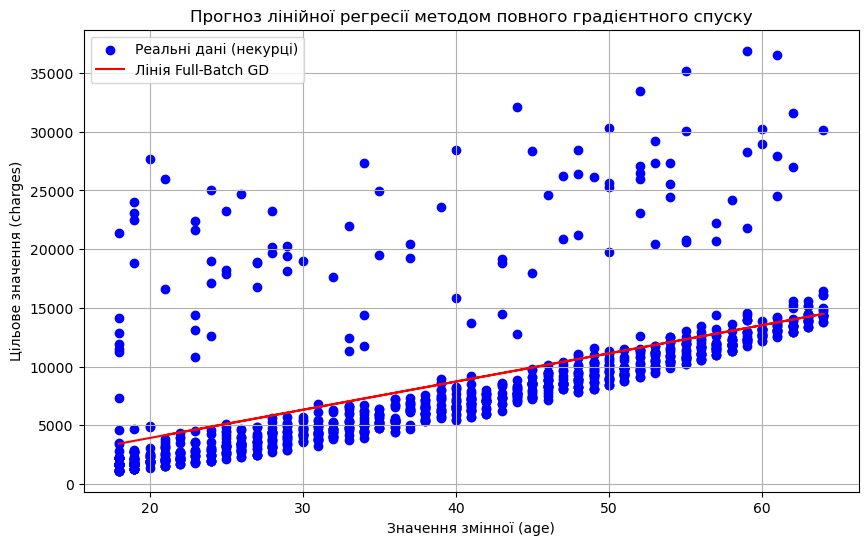

Root mean squared error для параметрів 240.4506453144176 та -901.2109654225544, знайдених методом повного градієнтного спуску: 4679.681930872782


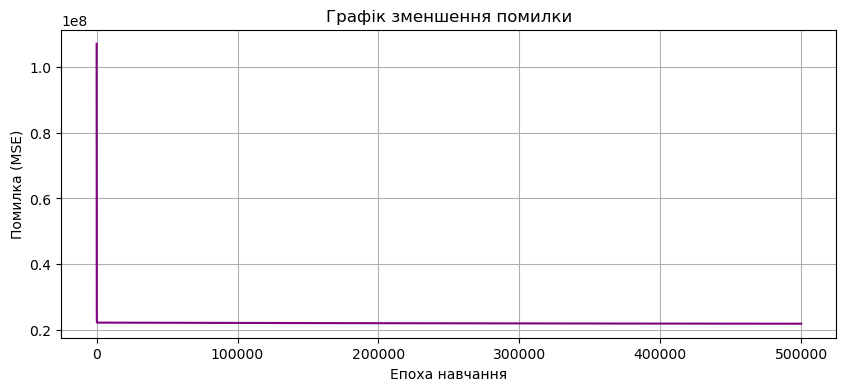

In [30]:
# 1.2. Відшукання найкращої лінії для прогнозу charges за ознакою age для некурців (датафрейм non_smoker_df) з допомогою
# методу Full-Batch градієнтного спуску (з використанням тільки numpy) (для lr = 0.000005, epochs = 500000)

# Запуск алгоритму (lr підібрано дуже малим, щоб уникнути розбіжності методу)
m, b, errors = full_batch_gradient_descent(X, y, lr = 0.000005, epochs = 500000)

# Побудова фінальних прогнозів моделі за допомогою знайдених коефіцієнтів m та b
predictions_fbgd = m * X + b

# Виведення отриманих коефіцієнтів лінійної регресії
print(f"Оптимальний коефіцієнт нахилу (m): {m}")
print(f"Оптимальний коефіцієнт зсуву (b): {b}")

# Створення графіку для візуалізації лінії регресії, знайденої методом повного (Full-Batch) градієнтного спуску, поверх реальних даних
plt.figure(figsize = (10, 6))
plt.scatter(X, y, color = 'blue', label = 'Реальні дані (некурці)')
plt.plot(X, predictions_fbgd, color = 'red', label = 'Лінія Full-Batch GD')
plt.xlabel('Значення змінної (age)')
plt.ylabel('Цільове значення (charges)')
plt.title('Прогноз лінійної регресії методом повного градієнтного спуску')
plt.legend()
plt.grid(True)
plt.show()

# Виведення root mean squared error для коефіцієнтів, обчислених методом повного градієнтного спуску
print(f"Root mean squared error для параметрів {m} та {b}, знайдених методом повного градієнтного спуску: {rmse_FBGD(non_smoker_df, m, b)}")

# Виведення графіка помилки залежно від ітерації
plt.figure(figsize = (10, 4))
plt.plot(errors, color = 'purple')
plt.xlabel('Епоха навчання')
plt.ylabel('Помилка (MSE)')
plt.title('Графік зменшення помилки')
plt.grid(True)
plt.show()

In [6]:
# Висновок
print("""Порівнявши значення Root mean squared error для кожного з трьох рейтів повного градієнтного спуску, бачимо, що найкраще (найменше) значення 
4679.681930872782 отримано для рейту lr = 0.000005, epochs = 500000
(коефіцієнт нахилу (m): 240.4506453144176, коефіцієнт зсуву (b): -901.2109654225544).""")

Порівнявши значення Root mean squared error для кожного з трьох рейтів повного градієнтного спуску, бачимо, що найкраще (найменше) значення 
4679.681930872782 отримано для рейту lr = 0.000005, epochs = 500000
(коефіцієнт нахилу (m): 240.4506453144176, коефіцієнт зсуву (b): -901.2109654225544)


In [31]:
# 1.3. Відшукання найкращої лінії для прогнозу charges за ознакою age для некурців (датафрейм non_smoker_df) з допомогою
# scikit-learn.LinearRegression

# Імпортування потрібних бібліотек
!pip install scikit-learn --quiet
from sklearn.linear_model import LinearRegression

# Визначення ознаки (вік)
X_non_smoker_series = non_smoker_df['age'] 

# Перетворення в датафрейм методом .to_frame()
X_non_smoker_f = X_non_smoker_series.to_frame()

# Задання лінійної регресії з допомогою scikit-learn.LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_non_smoker_f, y)

# Виведення отриманих коефіцієнтів лінійної регресії
print(f"Оптимальний коефіцієнт нахилу: {lin_reg.coef_[0]}")
print(f"Оптимальний коефіцієнт зсуву: {lin_reg.intercept_}")

# Задання прогнозованих значень
predictions_sklearn_non_smoker = lin_reg.predict(X_non_smoker_f)

# Імпортування вбудованої функції для обчислення root mean squared error зі scikit-learn
from sklearn.metrics import root_mean_squared_error

# Обчислення root mean squared error
rmse_value_non_smoker = root_mean_squared_error(y, predictions_sklearn_non_smoker)

# Виведення root mean squared error для коефіцієнтів, обчислених з допомогою scikit-learn.LinearRegression
print(f"Root mean squared error для параметрів {lin_reg.coef_[0]} та {lin_reg.intercept_}, знайдених з допомогою scikit-learn.LinearRegression: {rmse_value_non_smoker}")


Оптимальний коефіцієнт нахилу: 267.2489128311996
Оптимальний коефіцієнт зсуву: -2091.4205565650846
Root mean squared error для параметрів 267.2489128311996 та -2091.4205565650846, знайдених з допомогою scikit-learn.LinearRegression: 4662.505766636395


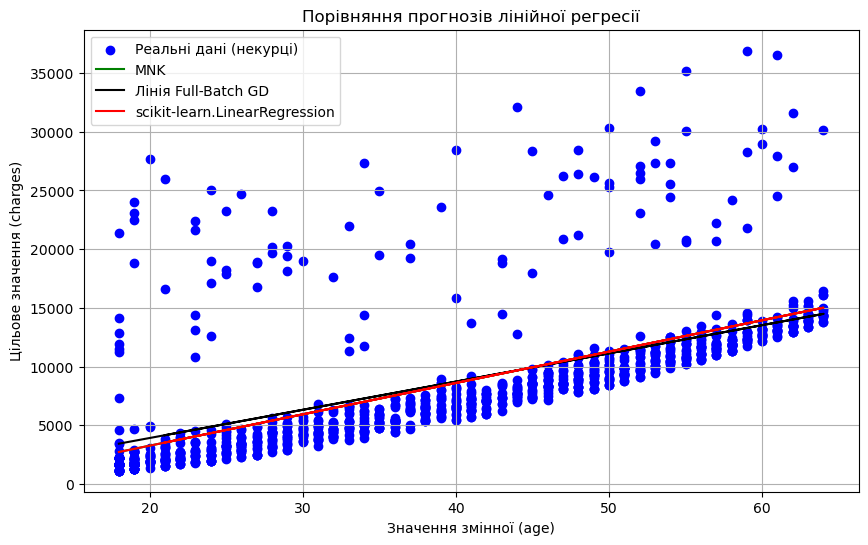

In [32]:
# Візуалізація прогнозів лінійної регресії та справжніх значень набору даних non_smoker_df

# Задання розмірів фігури
plt.figure(figsize = (10, 6))

# Задання справжніх значень набору даних non_smoker_df
plt.scatter(X, y, color = 'blue', label = 'Реальні дані (некурці)')

# Задання лінії передбачуваних значень для методу найменших квадратів
plt.plot(X, predictions_MNK, color = 'green', label = 'MNK')

# Задання лінії передбачуваних значень для повного градієнтного спуску (lr = 0.000005, epochs = 500000)
plt.plot(X, predictions_fbgd, color = 'black', label = 'Лінія Full-Batch GD')

# Задання лінії передбачуваних значень для методу scikit-learn.LinearRegression
plt.plot(X, predictions_sklearn_non_smoker, color = 'red', label = 'scikit-learn.LinearRegression')

# Задання підписів осей 0x, 0y, легенди та сітки
plt.title('Порівняння прогнозів лінійної регресії')
plt.xlabel('Значення змінної (age)')
plt.ylabel('Цільове значення (charges)')
plt.legend()
plt.grid(True)
    
# Виведення графіка
plt.show()

In [33]:
# Висновки

# Чи відрізняються результати моделей?
print("""Метод найменших квадратів та метод LinearRegression з бібліотеки scikit-learn у результаті дали однакову пряму лінію для
прогнозу медичних зборів (charges) за ознакою віку (age) для некурців. Ця лінія визначається коефіцієнтом нахилу 267.2489128311996 та 
коефіцієнтом зсуву -2091.4205565650846. Root mean squared error для цих параметрів становить 4662.505766636395. На графіку видно, що лінії цих 
двох методів перекривають одна одну.
Метод повного градієнтного спуску після трьох спроб для рейту lr = 0.000005, epochs = 500000 видав пряму лінію для прогнозу 
з коефіцієнтом нахилу 240.4506453144176, коефіцієнтом зсуву -901.2109654225544 та найкращим (мінімальним) значення root mean squared error 
4679.681930872782. Однак, як бачимо, це значення не є оптимальним, оскільки воно перевищує значення root mean squared error, отримане за допомогою 
двох інших методів.
Звідси можемо зробити висновок, що оптимальна пряма для прогнозу медичних зборів за ознакою віку для некурців отримана методом найменших квадратів 
та методом LinearRegression з бібліотеки scikit-learn.""")

# Чи є знайдені параметри моделі близькими до Ваших найкращих припущень?
print("""Мої найкращі припущення, отримані вручну в попередньому домашньому завданні, були такі: коефіцієнт нахилу прогнозної прямої 210 
(оптимальний 267.2489128311996), коефіцієнт зсуву 500 (оптимальний -2091.4205565650846) та значення root mean squared error для цих параметрів 
4743.5998138124805 (оптимальне 4662.505766636395). Як видно, між припущеними та оптимальними коефіцієнтами нахилу і значеннями root mean squared error 
різниця є невеликою, лише припущений та оптимальний коефіцієнти зсуву значно відрізняються.""")

Метод найменших квадратів та метод LinearRegression з бібліотеки scikit-learn у результаті дали однакову пряму лінію для
прогнозу медичних зборів (charges) за ознакою віку (age) для некурців. Ця лінія визначається коефіцієнтом нахилу 267.2489128311996 та 
коефіцієнтом зсуву -2091.4205565650846. Root mean squared error для цих параметрів становить 4662.505766636395. На графіку видно, що лінії цих 
двох методів перекривають одна одну.
Метод повного градієнтного спуску після трьох спроб для рейту lr = 0.000005, epochs = 500000 видав пряму лінію для прогнозу 
з коефіцієнтом нахилу 240.4506453144176, коефіцієнтом зсуву -901.2109654225544 та найкращим (мінімальним) значення root mean squared error 
4679.681930872782. Однак, як бачимо, це значення не є оптимальним, оскільки воно перевищує значення root mean squared error, отримане за допомогою 
двох інших методів.
Звідси можемо зробити висновок, що оптимальна пряма для прогнозу медичних зборів за ознакою віку для некурців отримана методом най

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних зборів для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

Оптимальний коефіцієнт нахилу: 305.23760210982874
Оптимальний коефіцієнт зсуву: 20294.12812691597
Коефіцієнт детермінації R^2 для scikit-learn.LinearRegression: 0.13558924096084068
Mean absolute error для scikit-learn.LinearRegression: 10097.80057785873
Root mean squared error для параметрів 305.23760210982874 та 20294.12812691597, знайдених з допомогою scikit-learn.LinearRegression: 10711.00334810241


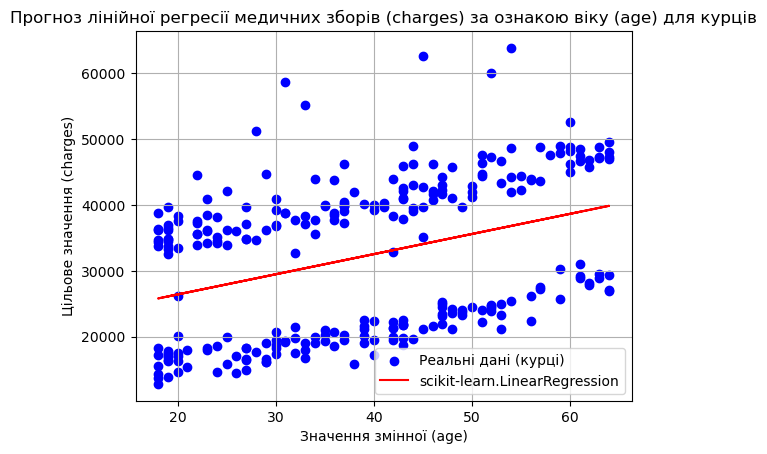

In [34]:
# 2. Відшукання найкращої лінії для прогнозу медичних зборів (charges) за ознакою віку (age) для курців (датафрейм smoker_df) з допомогою
# scikit-learn.LinearRegression

# Задання набору даних non_smoker_df для клієнтів страхової компанії, які курять
smoker_df = medical_df[medical_df.smoker == 'yes']

# Визначення ознаки (вік)
X_smoker_series = smoker_df['age'] 

# Визначення вектора цільових значень (медичні збори)
y_smoker = smoker_df['charges']

# Перетворення в датафрейм методом .to_frame()
X_smoker_f = X_smoker_series.to_frame()

# Задання лінійної регресії з допомогою scikit-learn.LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_smoker_f, y_smoker)

# Виведення отриманих коефіцієнтів лінійної регресії
print(f"Оптимальний коефіцієнт нахилу: {lin_reg.coef_[0]}")
print(f"Оптимальний коефіцієнт зсуву: {lin_reg.intercept_}")

# Задання прогнозованих значень
predictions_sklearn_smoker = lin_reg.predict(X_smoker_f)

# Вимірювання точності моделі

# Імпортування вбудованих функцій для обчислення коефіцієнту детермінації R^2 та mean absolute error зі scikit-learn
from sklearn.metrics import r2_score, mean_absolute_error

# Обчислення коефіцієнту детермінації R^2
r2 = r2_score(y_smoker, predictions_sklearn_smoker)

# Обчислення mean absolute error
mae = mean_absolute_error(y_smoker, predictions_sklearn_smoker)

# Обчислення root mean squared error
rmse_value_smoker = root_mean_squared_error(y_smoker, predictions_sklearn_smoker)

# Виведення коефіцієнту детермінації R^2
print(f"Коефіцієнт детермінації R^2 для scikit-learn.LinearRegression: {r2}")

# Виведення mean absolute error
print(f"Mean absolute error для scikit-learn.LinearRegression: {mae}")

# Виведення root mean squared error для коефіцієнтів, обчислених з допомогою scikit-learn.LinearRegression
print(f"Root mean squared error для параметрів {lin_reg.coef_[0]} та {lin_reg.intercept_}, знайдених з допомогою scikit-learn.LinearRegression: {rmse_value_smoker}")

# Візуалізація прогнозу лінійної регресії та справжніх значень набору даних smoker_df

# Задання справжніх значень набору даних smoker_df
plt.scatter(X_smoker_f, y_smoker, color = 'blue', label = 'Реальні дані (курці)')

# Задання лінії передбачуваних значень для методу scikit-learn.LinearRegression
plt.plot(X_smoker_f, predictions_sklearn_smoker, color = 'red', label = 'scikit-learn.LinearRegression')

# Задання підписів осей 0x, 0y, легенди та сітки
plt.title('Прогноз лінійної регресії медичних зборів (charges) за ознакою віку (age) для курців')
plt.xlabel('Значення змінної (age)')
plt.ylabel('Цільове значення (charges)')
plt.legend()
plt.grid(True)
    
# Виведення графіка
plt.show()

In [35]:
# Висновки

# Чи це хороша модель, чи ви б її використовували в компанії?
print("""Як видно з візуалізації даних та прогнозної прямої, дані мають значний розкид та розподілені на два великих віддалених сектори, які не можуть 
бути точно описані однією прямою лінією. Коефіцієнт детермінації R^2 (0.13558924096084068) моделі ближчий до 0, ніж до 1, що свідчить про низьку 
точність моделі. Mean absolute error (10097.80057785873) та root mean squared error (10711.00334810241) моделі досить близькі між собою та вказують 
на дуже велике відхилення між прогнозованими та справжніми значеннями даних. Тому цю модель краще не використовувати з огляду на дуже низьку якість 
її прогнозів.""")

Як видно з візуалізації даних та прогнозної прямої, дані мають значний розкид та розподілені на два великих віддалених сектори, які не можуть 
бути точно описані однією прямою лінією. Коефіцієнт детермінації R^2 (0.13558924096084068) моделі ближчий до 0, ніж до 1, що свідчить про низьку 
точність моделі. Mean absolute error (10097.80057785873) та root mean squared error (10711.00334810241) моделі досить близькі між собою та вказують 
на дуже велике відхилення між прогнозованими та справжніми значеннями даних. Тому цю модель краще не використовувати з огляду на дуже низьку якість 
її прогнозів.
